# 20 kV MV ring — transient analysis

Time-domain analysis of the same 20 kV medium-voltage ring as in the
companion notebook **MV ring (stationary)**: 20 substations linked by
0.5 km sections of NA2XS(F)2Y 1x300 RM/25 cable, `R_g = 5 Ohm` per
substation. We exercise the full transient stack:

* **Branch shunt capacitance is lumped automatically.** The state-space
  solver reads `Branch.C_self` and adds `C_self / 2` to each endpoint
  bus (pi-section).
* **Mutual coupling phase ↔ shield is part of the state-space solver.**
  With `R_mutual_formula` and `M_mutual_formula` populated, the Carson-
  style coupling that the FFT solver has always supported is now also
  evaluated in the time-domain ODE.

Three scenarios are shown:

1. FFT vs state-space, sinusoidal fault current with DC offset.
2. The same fault, but with the cable-shield mutual coupling zeroed
   out — to visualise its effect on the fault-bus EPR.
3. A Thévenin voltage source switched onto the ring at `t = 20 ms`.


In [1]:
import numpy as np
import matplotlib.pyplot as plt

import groundinsight as gi
from groundinsight.simulation import waveforms
from groundinsight.models.core_models import BusType, BranchType


## 1. Cable + bus parameters

Per-length values from the cable datasheet, plus the lumped totals at the chosen 0.5 km section length.

In [2]:
# Per-length (per km) shield-earth loop values for NA2XS(F)2Y 1x300 RM/25.
R_PER_KM = 0.25       # ohm / km
L_PER_KM = 1.9e-3     # H / km
C_PER_KM = 300e-9     # F / km
# Carson earth-return mutual values (typical for 50 Hz on this cable type).
R_MUT_PER_KM = 0.05   # ohm / km
M_PER_KM = 1.85e-3    # H / km

SECTION_LENGTH_KM = 0.5
N_BUSES = 20

R_BRANCH = R_PER_KM * SECTION_LENGTH_KM
L_BRANCH = L_PER_KM * SECTION_LENGTH_KM
C_BRANCH = C_PER_KM * SECTION_LENGTH_KM
M_BRANCH = M_PER_KM * SECTION_LENGTH_KM

# Bus grounding resistance (rod / strip / mat equivalent at each substation).
R_BUS = 5.0

# pi-section: the state-space solver adds C/2 from each adjacent branch
# to the bus -> in the closed ring, every bus accumulates one full
# C_BRANCH from its two halves. We keep the same total in the
# frequency-domain bus impedance so FFT and state-space see the same
# physics.
C_BUS_LUMPED = C_BRANCH

print(f"Per-section values (l = {SECTION_LENGTH_KM} km):")
print(f"  R_branch = {R_BRANCH*1e3:.1f} mohm")
print(f"  L_branch = {L_BRANCH*1e3:.2f} mH")
print(f"  C_branch = {C_BRANCH*1e9:.0f} nF")
print(f"  M_branch = {M_BRANCH*1e3:.2f} mH")
print(f"  Bus grounding resistance: R_bus = {R_BUS} ohm")
print(f"  Effective per-bus shunt capacitance after pi-lumping: {C_BUS_LUMPED*1e9:.0f} nF")


Per-section values (l = 0.5 km):
  R_branch = 125.0 mohm
  L_branch = 0.95 mH
  C_branch = 150 nF
  M_branch = 0.93 mH
  Bus grounding resistance: R_bus = 5.0 ohm
  Effective per-bus shunt capacitance after pi-lumping: 150 nF


## 2. Build the network

* `bus_type` carries only `R_formula` -- the bus capacitance is contributed by the adjacent branches via auto-lumping.
* `branch_type` carries `R_self_formula`, `L_self_formula`, `C_self_formula` (auto-lumped onto adjacent buses) plus `R_mutual_formula` and `M_mutual_formula` (consumed by the state-space solver as Carson coupling).
* For the FFT solver to see the same physics, the bus `impedance_formula` is set to the parallel combination `R || 1/(jwC_BUS_LUMPED)` (where `C_BUS_LUMPED = C_BRANCH` for this uniform ring) and the branch `mutual_impedance_formula` is `R_mutual + jwM`.

In [3]:
# Frequency-domain bus impedance: R || (1 / (j*omega*C_lumped)).
# C_lumped equals what the state-space solver gets from the adjacent
# branches' pi-section contributions; FFT and state-space therefore
# see the same physics.
Z_bus_formula = (
    f"((rho * 0 + {R_BUS}) / (1 + I * 2 * pi * f * {R_BUS} * {C_BUS_LUMPED}))"
)

bus_type = BusType(
    name="MV_substation",
    description="20 kV substation grounding, 5 ohm; cable C lumped automatically",
    system_type="Substation",
    voltage_level=20.0,
    impedance_formula=Z_bus_formula,
    R_formula=f"rho * 0 + {R_BUS}",
    # No explicit bus C: the per-cable shunt comes from the branch
    # C_self_formula via the state-space solver's pi-lumping.
)

Z_self_formula = (
    f"((rho * 0 + {R_PER_KM}) + I * 2 * pi * f * {L_PER_KM}) * l"
)
Z_mutual_formula = (
    f"((rho * 0 + {R_MUT_PER_KM}) + I * 2 * pi * f * {M_PER_KM}) * l"
)
branch_type = BranchType(
    name="NA2XS_300_25",
    description="NA2XS(F)2Y 1x300 RM/25 with Carson mutual coupling",
    grounding_conductor=True,
    self_impedance_formula=Z_self_formula,
    mutual_impedance_formula=Z_mutual_formula,
    R_self_formula=f"({R_PER_KM}) * l",
    L_self_formula=f"({L_PER_KM}) * l",
    C_self_formula=f"({C_PER_KM}) * l",
    R_mutual_formula=f"({R_MUT_PER_KM}) * l",
    M_mutual_formula=f"({M_PER_KM}) * l",
)

net = gi.create_network(name="mv_ring_20", frequencies=[50.0])
for k in range(1, N_BUSES + 1):
    gi.create_bus(name=f"b{k:02d}", type=bus_type, network=net)
for k in range(1, N_BUSES + 1):
    nxt = (k % N_BUSES) + 1
    gi.create_branch(
        name=f"L_{k:02d}_{nxt:02d}",
        type=branch_type,
        from_bus=f"b{k:02d}",
        to_bus=f"b{nxt:02d}",
        length=SECTION_LENGTH_KM,
        network=net,
    )

print(f"Network: {len(net.buses)} buses, {len(net.branches)} branches")


Network: 20 buses, 20 branches


In [ ]:
# Source / fault setup shared by all transient scenarios.
gi.create_source(name="src", bus="b01", values={50.0: 1000.0 + 0.0j}, network=net)
gi.create_fault(name="F1", bus="b10", scalings={50.0: 1.0}, network=net)
gi.create_paths(network=net)


## 4. FFT vs state-space, mutual coupling on

Same fault current waveform as before. The two solvers must agree on the forced response in the on-window because both now see the mutual coupling and both auto-derive the bus shunt capacitance from the same physical parameters (FFT via `impedance_formula`, state-space via the pi-lumping).

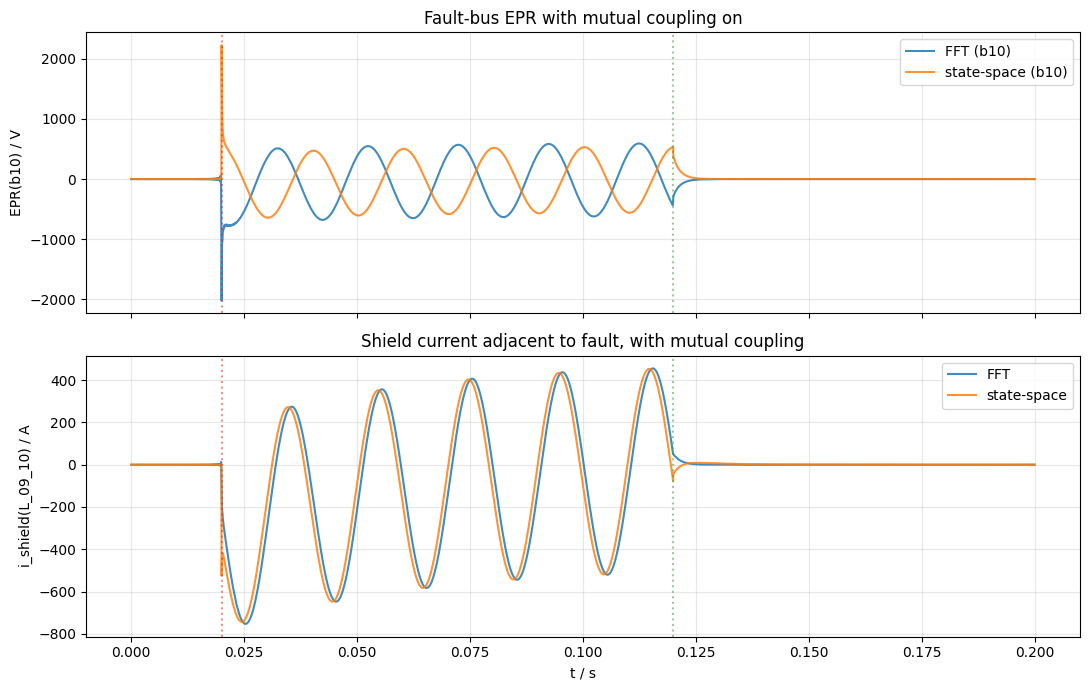

In [5]:
fault_current = waveforms.sinusoidal_with_dc_offset(
    amplitude=1000.0,
    frequency_hz=50.0,
    t_on=0.02,
    t_off=0.12,
    dc_amplitude=600.0,
    dc_decay_tau=0.04,
)
obs_buses = ["b01", "b05", "b10", "b15", "b20"]
obs_branches = ["L_09_10", "L_10_11"]

study_fft = gi.TransientStudy(net, fault_name="F1")
study_fft.set_source_waveform("src", fault_current)
study_fft.set_observation(buses=obs_buses, branches=obs_branches)
result_fft = study_fft.solve(t_end=0.2, dt=1e-4, solver="fft")

study_ss = gi.TransientStudy(net, fault_name="F1")
study_ss.set_source_waveform("src", fault_current)
study_ss.set_observation(buses=obs_buses, branches=obs_branches)
result_ss = study_ss.solve(t_end=0.2, dt=5e-5, solver="state_space")

fig, axes = plt.subplots(2, 1, figsize=(11, 7), sharex=True)
ax = axes[0]
ax.plot(result_fft.time_s, result_fft.epr_t["b10"], label="FFT (b10)", alpha=0.85)
ax.plot(result_ss.time_s, result_ss.epr_t["b10"], label="state-space (b10)", alpha=0.85)
ax.axvline(0.02, color="tab:red", ls=":", alpha=0.5)
ax.axvline(0.12, color="tab:green", ls=":", alpha=0.5)
ax.set_ylabel("EPR(b10) / V"); ax.set_title("Fault-bus EPR with mutual coupling on")
ax.grid(True, alpha=0.3); ax.legend(loc="upper right")

ax = axes[1]
ax.plot(result_fft.time_s, result_fft.i_branch_t["L_09_10"], label="FFT", alpha=0.85)
ax.plot(result_ss.time_s, result_ss.i_branch_t["L_09_10"], label="state-space", alpha=0.85)
ax.axvline(0.02, color="tab:red", ls=":", alpha=0.5)
ax.axvline(0.12, color="tab:green", ls=":", alpha=0.5)
ax.set_xlabel("t / s"); ax.set_ylabel("i_shield(L_09_10) / A")
ax.set_title("Shield current adjacent to fault, with mutual coupling")
ax.grid(True, alpha=0.3); ax.legend(loc="upper right")
fig.tight_layout(); plt.show()


### Effect of the mutual coupling on the fault-bus EPR

We rerun the FFT solver with the mutual term zeroed out and overlay the two traces to see how much the cable shield reduces the EPR at the fault location.

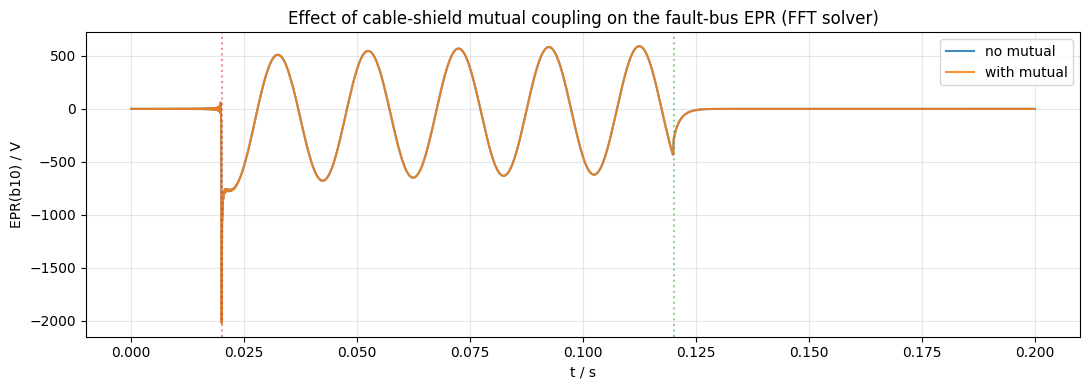

Reduction factor with mutual:    r = 0.904
Reduction factor without mutual: r = 1.000


In [6]:
branch_type_no_mut = BranchType(
    name="NA2XS_300_25_no_mut",
    grounding_conductor=True,
    self_impedance_formula=Z_self_formula,
    mutual_impedance_formula="(rho * 0 + 0.0) * l",
    R_self_formula=f"({R_PER_KM}) * l",
    L_self_formula=f"({L_PER_KM}) * l",
    C_self_formula=f"({C_PER_KM}) * l",
)
net_no_mut = gi.create_network(name="mv_ring_no_mut", frequencies=[50.0])
for k in range(1, N_BUSES + 1):
    gi.create_bus(name=f"b{k:02d}", type=bus_type, network=net_no_mut)
for k in range(1, N_BUSES + 1):
    nxt = (k % N_BUSES) + 1
    gi.create_branch(
        name=f"L_{k:02d}_{nxt:02d}",
        type=branch_type_no_mut,
        from_bus=f"b{k:02d}",
        to_bus=f"b{nxt:02d}",
        length=SECTION_LENGTH_KM,
        network=net_no_mut,
    )
gi.create_source(name="src", bus="b01", values={50.0: 1000.0 + 0.0j}, network=net_no_mut)
gi.create_fault(name="F1", bus="b10", scalings={50.0: 1.0}, network=net_no_mut)
gi.create_paths(network=net_no_mut)

study_no_mut = gi.TransientStudy(net_no_mut, fault_name="F1")
study_no_mut.set_source_waveform("src", fault_current)
study_no_mut.set_observation(buses=obs_buses)
res_no_mut = study_no_mut.solve(t_end=0.2, dt=1e-4, solver="fft")

fig, ax = plt.subplots(figsize=(11, 4))
ax.plot(res_no_mut.time_s, res_no_mut.epr_t["b10"], label="no mutual", alpha=0.85)
ax.plot(result_fft.time_s, result_fft.epr_t["b10"], label="with mutual", alpha=0.85)
ax.axvline(0.02, color="tab:red", ls=":", alpha=0.5)
ax.axvline(0.12, color="tab:green", ls=":", alpha=0.5)
ax.set_xlabel("t / s"); ax.set_ylabel("EPR(b10) / V")
ax.set_title("Effect of cable-shield mutual coupling on the fault-bus EPR (FFT solver)")
ax.grid(True, alpha=0.3); ax.legend()
fig.tight_layout(); plt.show()

rf_no = net_no_mut.results.get("F1")
if rf_no is None:
    gi.run_fault(net_no_mut, fault_name="F1")
rf_no = net_no_mut.results["F1"].reduction_factor.value[50.0]
print(f"Reduction factor with mutual:    r = {net.results['F1'].reduction_factor.value[50.0]:.3f}")
print(f"Reduction factor without mutual: r = {rf_no:.3f}")


## 5. Thevenin source switched onto the ring

Same Thevenin scenario as before, now with mutual coupling and pi-lumped branch capacitance both modelled. The first 20 ms after the EMF step show the L/C interactions; afterwards the steady-state 50 Hz response settles.

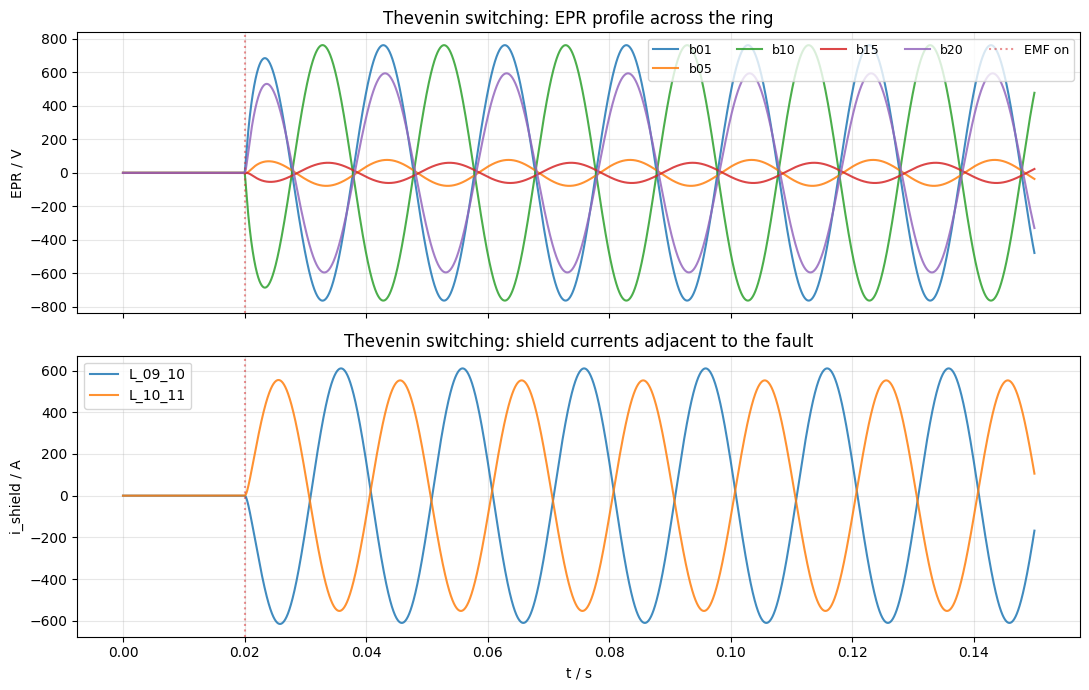

In [7]:
net_v = gi.create_network(name="mv_ring_thevenin", frequencies=[50.0])
for k in range(1, N_BUSES + 1):
    gi.create_bus(name=f"b{k:02d}", type=bus_type, network=net_v)
for k in range(1, N_BUSES + 1):
    nxt = (k % N_BUSES) + 1
    gi.create_branch(
        name=f"L_{k:02d}_{nxt:02d}",
        type=branch_type,
        from_bus=f"b{k:02d}",
        to_bus=f"b{nxt:02d}",
        length=SECTION_LENGTH_KM,
        network=net_v,
    )

U_phase = 20e3 / np.sqrt(3)
R_src = 12.0
L_src = 3e-3
Z_src_50 = R_src + 1j * 2 * np.pi * 50.0 * L_src
gi.create_voltage_source(
    name="vsrc",
    bus="b01",
    voltage={50.0: U_phase + 0.0j},
    source_impedance={50.0: Z_src_50},
    network=net_v,
)
gi.create_fault(name="F1", bus="b10", scalings={50.0: 1.0}, network=net_v)
gi.create_paths(network=net_v)

U_peak = U_phase * np.sqrt(2)
emf = waveforms.sinusoidal_with_dc_offset(
    amplitude=U_peak, frequency_hz=50.0, t_on=0.02, t_off=None,
)
study_v = gi.TransientStudy(net_v, fault_name="F1")
study_v.set_source_waveform("vsrc", emf)
study_v.set_observation(buses=obs_buses, branches=obs_branches)
result_v = study_v.solve(t_end=0.15, dt=2e-5, solver="state_space")

fig, axes = plt.subplots(2, 1, figsize=(11, 7), sharex=True)
ax = axes[0]
for b in obs_buses:
    ax.plot(result_v.time_s, result_v.epr_t[b], label=b, alpha=0.85)
ax.axvline(0.02, color="tab:red", ls=":", alpha=0.5, label="EMF on")
ax.set_ylabel("EPR / V"); ax.set_title("Thevenin switching: EPR profile across the ring")
ax.grid(True, alpha=0.3); ax.legend(loc="upper right", ncols=5, fontsize=9)

ax = axes[1]
for br in obs_branches:
    ax.plot(result_v.time_s, result_v.i_branch_t[br], label=br, alpha=0.85)
ax.axvline(0.02, color="tab:red", ls=":", alpha=0.5)
ax.set_xlabel("t / s"); ax.set_ylabel("i_shield / A")
ax.set_title("Thevenin switching: shield currents adjacent to the fault")
ax.grid(True, alpha=0.3); ax.legend()
fig.tight_layout(); plt.show()


## Take-aways

* `C_self_formula` on the cable type is enough -- the state-space solver lumps it onto the adjacent buses automatically (pi-section). The user does not need to maintain a duplicate `C_formula` on the bus type.
* `R_mutual_formula` and `M_mutual_formula` are now consumed by both solvers. The mutual coupling reduces the EPR at the fault bus and shows up in the steady-state reduction factor; for typical MV cable parameters the effect is in the 10-30 % range.
* FFT and state-space agree on the forced response when both formula sets describe the same physics (same `R || C` bus impedance, same `R + jwL` branch self impedance, same `R_mutual + jwM` mutual impedance). The state-space solver adds value at the switching edges (ring-down after fault clear, on-event ringing for the Thevenin scenario) -- the part where FFT cannot resolve the topology dynamics.
* Mutual coupling in the state-space solver is currently restricted to current sources (the path-based phase-current factor uses the source waveform directly). Voltage sources skip the mutual contribution and emit a one-time warning; once a state-dependent loop current can be threaded into the mutual feedforward this restriction will be lifted.